In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, classification_report)
import joblib
import json
import os
import time

Lade Daten...
Train Shape: (202944, 16), Test Shape: (50736, 16)
Diabetes Rate im Training: 13.93%

Starte Hyperparameter-Optimierung (RandomizedSearchCV)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Optimierung fertig in 118.8 Sekunden.
Beste Parameter: {'clf__n_estimators': 100, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 4, 'clf__max_depth': 10}
Bester CV-Recall: 0.762

=== Modell Evaluation (Test Set) ===
Accuracy:  0.729
Precision: 0.309
Recall:    0.764
F1-Score:  0.440
AUC-ROC:   0.821

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       0.95      0.72      0.82     43667
         1.0       0.31      0.76      0.44      7069

    accuracy                           0.73     50736
   macro avg       0.63      0.74      0.63     50736
weighted avg       0.86      0.73      0.77     50736


Modell gespeichert unter: ../ml/model\diabetes_pipeline.pkl
Metriken gespeichert unter: ../ml/model\metrics.json


C:\Users\Alexa\AppData\Local\Temp\ipykernel_10736\310147745.py:110: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=importances.head(10), palette='viridis')


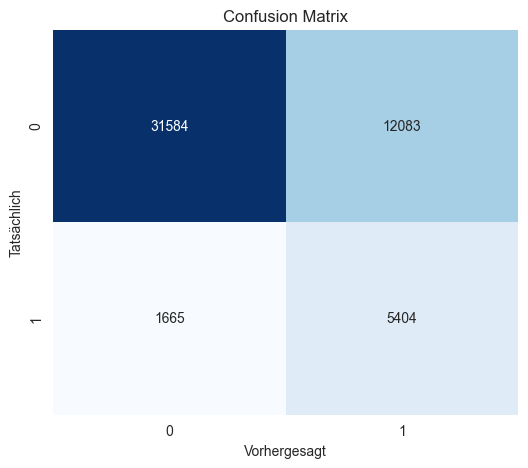

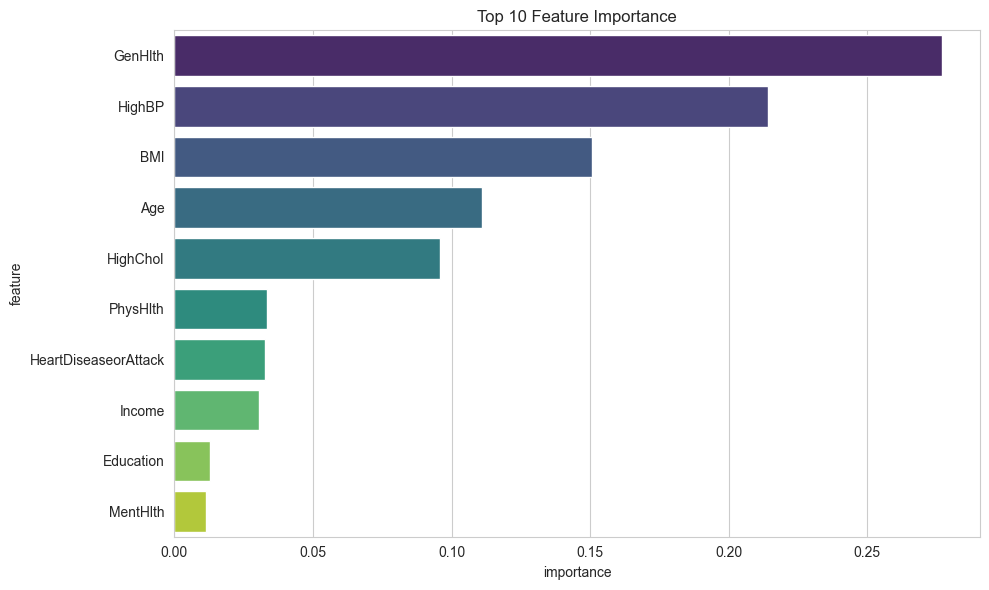

In [2]:
#Ziel: ML-Modell trainieren und evaluieren 

# Einstellungen
sns.set_style("whitegrid")
MODEL_DIR = '../ml/model'
DATA_PATH = '../data/diabetes_binary_health_indicators_BRFSS2015.csv'
FEATURES_PATH = os.path.join(MODEL_DIR, 'selected_features.json')

# 1 Daten & Features laden
print("Lade Daten...")
if not os.path.exists(DATA_PATH) or not os.path.exists(FEATURES_PATH):
    print("Fehler: Daten oder Features-Datei nicht gefunden. Bitte Teil 1 ausführen.")
    exit()
    
df = pd.read_csv(DATA_PATH)

with open(FEATURES_PATH, 'r') as f:
    selected_features = json.load(f)

X = df[selected_features]
y = df['Diabetes_binary']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train Shape: {X_train.shape}, Test Shape: {X_test.shape}")
print(f"Diabetes Rate im Training: {y_train.mean():.2%}")

# 2 Pipeline & Hyperparameter Optimierung

# Pipeline definieren: Skalierung -> Modell
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'))
])

# Hyperparameter-Raum für RandomizedSearch
# Sucht nach besseren Werten als den fest codierten
param_dist = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15, 20, None],
    'clf__min_samples_split': [2, 5, 10],
    'clf__min_samples_leaf': [1, 2, 4]
}

print("\nStarte Hyperparameter-Optimierung (RandomizedSearchCV)...")
start_time = time.time()

# RandomizedSearchCV
search = RandomizedSearchCV(
    pipeline, 
    param_distributions=param_dist, 
    n_iter=10, # Anzahl der Kombinationen die getestet werden
    cv=3,      # 3-Fold Cross Validation
    scoring='recall', # Wir optimieren auf Recall (wichtig bei Krankheiten!)
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
end_time = time.time()

print(f"Optimierung fertig in {end_time - start_time:.1f} Sekunden.")
print(f"Beste Parameter: {search.best_params_}")
print(f"Bester CV-Recall: {search.best_score_:.3f}")

# Bestes Modell extrahieren
best_model = search.best_estimator_

# 3 Evaluation

y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n=== Modell Evaluation (Test Set) ===")
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-Score:  {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Confusion Matrix Plot
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.ylabel('Tatsächlich')
plt.xlabel('Vorhergesagt')
#plt.show()
plt.savefig('../ml/results/Konfusionsmatrix.png')

# 4 Feature Importance
rf_model = best_model.named_steps['clf']
importances = pd.DataFrame({
    'feature': selected_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances.head(10), palette='viridis')
plt.title('Top 10 Feature Importance')
plt.tight_layout()
#plt.show()
plt.savefig('../ml/results/Top_10_Features')

# 5 Speichern

os.makedirs(MODEL_DIR, exist_ok=True)

# Modell speichern
model_path = os.path.join(MODEL_DIR, 'diabetes_pipeline.pkl')
joblib.dump(best_model, model_path)

# Metriken speichern (für Vergleichbarkeit)
metrics = {
    'accuracy': acc,
    'precision': prec,
    'recall': rec,
    'f1': f1,
    'auc': auc,
    'best_params': search.best_params_
}

metrics_path = os.path.join(MODEL_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)

print(f"\nModell gespeichert unter: {model_path}")
print(f"Metriken gespeichert unter: {metrics_path}")